#### Team members
 
1. Mostafa Allahmoradi - 9087818
2. Cemil Caglar Yapici – 9081058
3. Jarius Bedward - 8841640

#### Problem statement
 
Area of Focus:  
Obesity has become one of the most common global health issues of the 21st century. It is associated with a higher risk of other diseases such as diabetes, heart attack, and certain cancers. Diet quality plays a critical role in determining an individual’s risk of becoming overweight or obese. With the increasing availability of data on dietary intake (protein, sugar, and sodium), machine learning offers a powerful approach to predict obesity risk.
 
Objective:
1. To preprocess and analyze a dataset containing dietary information.
2. To identify correlations between diet quality and obesity.
3. To train and evaluate multiple machine learning models for predicting obesity levels.
4. To determine which features most strongly influence obesity outcomes.
5. To deploy or visualize a predictive model that can estimate obesity risk for new individuals.
 
Expected Outcome: A reliable machine learning model capable of predicting obesity levels with high accuracy based on dietary inputs.
 
This project aims to explore how machine learning can help predict the likelihood of developing obesity based on an individual’s diet quality. By analyzing real-world health data, our goal is to identify key risk factors and build a predictive model that can help individuals take proactive measures toward healthier living.

#### Hypothesis
 
🧪 Main Hypothesis
Null Hypothesis (H₀):
 
There is a significant relationship between an individual's diet quality and their obesity level.
That is, calory and dietary intake (protein, sugar, and sodium) can be used to accurately predict whether an individual is obese, overweight, or normal-weight.
 
Alternative Hypothesis (H₁):
 
There is no significant relationship between an individual's diet quality and their obesity level.
In other words, diet-related features (such as calorie intake, junk food frequency, fruit/vegetable intake, and physical activity) do not help predict obesity status better than random chance.

#### 100-word summary update of the use case
 
This project aims to predict obesity levels based on diet quality, focusing on calorie intake and nutrient composition, including protein, sugar, and sodium consumption. The goal is to identify how these dietary factors influence obesity risk. Machine learning algorithms are applied to analyze the relationship between nutritional intake and obesity classification. The revised hypothesis testing defines the null hypothesis (H₀) as a significant relationship existing between diet quality and obesity level, while the alternative hypothesis (H₁) states that there is no significant relationship between these factors. This update refines the project’s focus toward nutritional impact on obesity prediction.

#### Import statements

In [132]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import boxcox
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan





#### Load dataset

In [133]:
macro_dataset = pd.read_csv('data/detailed_meals_macros_.csv')

display(macro_dataset.head(5))
display(macro_dataset.info())

display(macro_dataset.describe().T)

,Ages,Gender,Height,Weight,Activity Level,Dietary Preference,Daily Calorie Target,Protein,Sugar,Sodium,...,Dinner Calories,Dinner Protein.1,Dinner Carbohydrates.1,Dinner Fats,Snack Suggestion,Snacks Calories,Snacks Protein,Snacks Carbohydrates,Snacks Fats,Disease
0,25,Male,180,80,Moderately Active,Omnivore,2000,120,125.0,24.0,...,2020.0,60.0,250.0,60.0,Greek yogurt with fruit,150,10,20,5,Weight Gain
1,32,Female,165,65,Lightly Active,Vegetarian,1600,80,100.0,16.0,...,10.0,5.0,31.0,27.0,Apple with almond butter,180,4,30,8,"Weight Gain, Hypertension, Heart Disease"
2,48,Male,175,95,Sedentary,Vegan,2200,100,150.0,20.0,...,326.0,55.0,150.0,15.0,Trail mix,300,8,34,20,Weight Gain
3,55,Female,160,70,Very Active,Omnivore,2500,140,175.0,28.0,...,278.0,20.0,163.0,27.0,Banana with peanut butter,210,5,30,9,Weight Gain
4,62,Male,170,85,Sedentary,Vegetarian,2000,80,125.0,16.0,...,186.0,6.3,186.0,22.0,Fruit and nut mix,250,6,28,15,Weight Gain


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1698 entries, 0 to 1697
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Ages                     1698 non-null   int64  
 1   Gender                   1698 non-null   object 
 2   Height                   1698 non-null   int64  
 3   Weight                   1698 non-null   int64  
 4   Activity Level           1698 non-null   object 
 5   Dietary Preference       1698 non-null   object 
 6   Daily Calorie Target     1698 non-null   int64  
 7   Protein                  1698 non-null   int64  
 8   Sugar                    1698 non-null   float64
 9   Sodium                   1698 non-null   float64
 10  Calories                 1698 non-null   int64  
 11  Carbohydrates            1698 non-null   int64  
 12  Fiber                    1698 non-null   float64
 13  Fat                      1698 non-null   int64  
 14  Breakfast Suggestion    

None

,count,mean,std,min,25%,50%,75%,max
Ages,1698.0,43.961720,15.915002,18.0,30.0000,42.00,57.000,79.00
Height,1698.0,174.130153,13.420936,150.0,163.2500,174.00,185.000,200.00
Weight,1698.0,78.064193,16.949264,48.0,64.0000,78.00,91.000,119.00
Daily Calorie Target,1698.0,2275.171967,558.812405,1200.0,1800.0000,2200.00,2689.000,4364.00
Protein,1698.0,139.898115,53.326588,50.0,100.0000,136.00,174.000,327.00
Sugar,1698.0,126.192580,34.938902,60.0,100.0000,124.00,150.000,218.00
Sodium,1698.0,27.979623,10.665318,10.0,20.0000,27.20,34.800,65.40
Calories,1698.0,2196.440518,571.089569,990.0,1770.2500,2146.00,2549.750,4357.00
Carbohydrates,1698.0,252.385159,69.877804,120.0,200.0000,248.00,300.000,436.00
Fiber,1698.0,30.286219,8.385337,14.4,24.0000,29.76,36.000,52.32


#### Setup
- This setups the BMI calculations and the features as well as standardizes the numeric features

In [134]:
# Calculate BMI
macro_dataset['Height_m'] = macro_dataset['Height'] / 100  # convert cm → m
macro_dataset['BMI'] = macro_dataset['Weight'] / (macro_dataset['Height_m'] ** 2)

# Create target variable for Obesity (1 if BMI >= 30)
macro_dataset['Obesity'] = np.where(macro_dataset['BMI'] >= 30, 1, 0)

#Select relevant features
features = [
    'Daily Calorie Target', 'Calories', 'Protein', 'Sugar', 'Sodium',
    'Carbohydrates', 'Fiber', 'Fat', 'Activity Level', 'Dietary Preference'
]

x = macro_dataset[features].copy()
y = macro_dataset['Obesity']

le = LabelEncoder()
for col in ["Activity Level", "Dietary Preference"]:
    x[col] = le.fit_transform(x[col])


# Standardize numeric features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

#Summary

print("Setup Complete")
print("Features matrix shape:", X_scaled.shape)
print("Target distribution (0=not obese), 1=Obese):\n", y.value_counts())
X_scaled.head()


Setup Complete
Features matrix shape: (1698, 10)
Target distribution (0=not obese), 1=Obese):
 Obesity
0    1329
1     369
Name: count, dtype: int64


,Daily Calorie Target,Calories,Protein,Sugar,Sodium,Carbohydrates,Fiber,Fat,Activity Level,Dietary Preference
0,-0.492568,-0.309045,-0.373247,-0.034143,-0.373247,-0.034143,-0.034143,-0.452793,-0.196012,-1.263487
1,-1.208582,-1.254885,-1.123563,-0.749889,-1.123563,-0.749889,-0.749889,-1.386309,-1.001893,1.235039
2,-0.134561,-0.020039,-0.748405,0.681602,-0.748405,0.681602,0.681602,-0.219415,0.609868,0.402197
3,0.402450,0.846981,0.001911,1.397348,0.001911,1.397348,1.397348,0.480722,1.415749,-1.263487
4,-0.492568,-0.668114,-1.123563,-0.034143,-1.123563,-0.034143,-0.034143,-0.686172,0.609868,1.235039


## Basic Cleaning of  data
- Removing trailing spaces
- Drop rows with missing target variables
- Fill or drop missing values


In [135]:

# Remove trailing spaces
macro_dataset = macro_dataset.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Normalize text casing for categorical columns
text_cols = ['Gender', 'Activity Level', 'Dietary Preference', 'Disease']
for col in text_cols:
    if col in macro_dataset.columns:
        macro_dataset[col] = macro_dataset[col].str.title()


#Remove duplicate rows
macro_dataset.drop_duplicates(inplace=True)

#Summary & Check
print("Data cleaned successfully!\n")
print("Remaining missing values per column:\n", macro_dataset.isnull().sum())
print("\nData shape after cleaning:", macro_dataset.shape)
print("\nUnique Dietary Preferences:", macro_dataset['Dietary Preference'].unique())
print("Unique Diseases:", macro_dataset['Disease'].unique())

Data cleaned successfully!

Remaining missing values per column:
 Ages                       0
Gender                     0
Height                     0
Weight                     0
Activity Level             0
Dietary Preference         0
Daily Calorie Target       0
Protein                    0
Sugar                      0
Sodium                     0
Calories                   0
Carbohydrates              0
Fiber                      0
Fat                        0
Breakfast Suggestion       0
Breakfast Calories         0
Breakfast Protein          0
Breakfast Carbohydrates    1
Breakfast Fats             0
Lunch Suggestion           0
Lunch Calories             0
Lunch Protein              0
Lunch Carbohydrates        0
Lunch Fats                 0
Dinner Suggestion          0
Dinner Calories            0
Dinner Protein.1           0
Dinner Carbohydrates.1     0
Dinner Fats                0
Snack Suggestion           0
Snacks Calories            0
Snacks Protein             0
Snacks

### 5.Extensive cleanup and data source preparation

##### 5.1 Missing Values Ratio: column-based deficiency ratio elimination

In [136]:
# 5.1.1 – Calculate the missing percentages (ccy)

missing_ratio_ccy = macro_dataset.isna().mean().sort_values(ascending=False)
print("The 15 columns with the highest deficiency rate:\n", missing_ratio_ccy.head(15))

# Threshold: Let's exclude columns with a deficiency rate of 30% or higher (typically, a range of 20–40% is preferred in courses).
MISSING_THRESH = 0.30

drop_cols_missing_ccy = missing_ratio_ccy[missing_ratio_ccy > MISSING_THRESH].index.tolist()
print(f"\nShortage ratio > {MISSING_THRESH:.0%} Number of columns that exist and will be removed: {len(drop_cols_missing_ccy)}")
print(drop_cols_missing_ccy)

# 5.1.2 – remove columns
df_mv_filtered_ccy = macro_dataset.drop(columns=drop_cols_missing_ccy)
print("\nFigure (before/after):", macro_dataset.shape, "->", df_mv_filtered_ccy.shape)


The 15 columns with the highest deficiency rate:
 Breakfast Carbohydrates    0.000589
Ages                       0.000000
Height                     0.000000
Weight                     0.000000
Activity Level             0.000000
Gender                     0.000000
Dietary Preference         0.000000
Daily Calorie Target       0.000000
Sugar                      0.000000
Protein                    0.000000
Calories                   0.000000
Carbohydrates              0.000000
Fiber                      0.000000
Sodium                     0.000000
Fat                        0.000000
dtype: float64

Shortage ratio > 30% Number of columns that exist and will be removed: 0
[]

Figure (before/after): (1698, 38) -> (1698, 38)


##### 5.2 Low Variance Filter: (elimination of low-variance features)

We proceed along two paths below:

-Numeric columns: VarianceThreshold (sklearn)

-Categorical columns: “near-zero variance” intuition (if the dominant category ratio is very high)

In [137]:
# 5.2.0 – Seperation of spice
num_cols_ccy = df_mv_filtered_ccy.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_ccy = df_mv_filtered_ccy.select_dtypes(exclude=[np.number]).columns.tolist()
num_cols_ccy, cat_cols_ccy[:10]


(['Ages',
  'Height',
  'Weight',
  'Daily Calorie Target',
  'Protein',
  'Sugar',
  'Sodium',
  'Calories',
  'Carbohydrates',
  'Fiber',
  'Fat',
  'Breakfast Calories',
  'Breakfast Protein',
  'Breakfast Carbohydrates',
  'Breakfast Fats',
  'Lunch Calories',
  'Lunch Protein',
  'Lunch Carbohydrates',
  'Lunch Fats',
  'Dinner Calories',
  'Dinner Protein.1',
  'Dinner Carbohydrates.1',
  'Dinner Fats',
  'Snacks Calories',
  'Snacks Protein',
  'Snacks Carbohydrates',
  'Snacks Fats',
  'Height_m',
  'BMI',
  'Obesity'],
 ['Gender',
  'Activity Level',
  'Dietary Preference',
  'Breakfast Suggestion',
  'Lunch Suggestion',
  'Dinner Suggestion',
  'Snack Suggestion',
  'Disease'])

##### 5.2.1 Low variance filter for numerical columns

In [138]:
# 5.2.1 – 
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

num_imputer_ccy = SimpleImputer(strategy="median")
X_num_ccy = pd.DataFrame(
    num_imputer_ccy.fit_transform(df_mv_filtered_ccy[num_cols_ccy]),
    columns=num_cols_ccy,
    index=df_mv_filtered_ccy.index
)

# 
num_variances_ccy = X_num_ccy.var().sort_values()
print("The 10 columns with the lowest variance:\n", num_variances_ccy.head(10))

# Threshold selection:
# - If features are not standardized, 0.0 is a good starting point (discards completely constant or nearly constant variables)
# - Alternative: discard the bottom 5% (present in the comment line)
MIN_VAR_THRESH = 0.0
# MIN_VAR_THRESH = num_variances_ccy.quantile(0.05)

vt_ccy = VarianceThreshold(threshold=MIN_VAR_THRESH)
X_num_kept = vt_ccy.fit_transform(X_num_ccy)
kept_num_mask_ccy = vt_ccy.get_support()
kept_num_cols_ccy = list(X_num_ccy.columns[kept_num_mask_ccy])
dropped_num_cols_ccy = [c for c in X_num_ccy.columns if c not in kept_num_cols_ccy]

print(f"\nNumber of numerical columns discarded due to low variance: {len(dropped_num_cols_ccy)}")
print(dropped_num_cols_ccy)


The 10 columns with the lowest variance:
 Height_m                  0.018012
Obesity                   0.170189
Lunch Fats                5.197548
Snacks Protein           16.682242
BMI                      41.261419
Snacks Fats              49.450518
Fiber                    70.313869
Sodium                  113.749001
Breakfast Fats          136.779765
Snacks Carbohydrates    161.595108
dtype: float64

Number of numerical columns discarded due to low variance: 0
[]


##### 5.2.2 “Near-zero variance” filter for categorical columns

In [139]:
# 5.2.2 –
from collections import Counter

def find_near_zero_var_cats_ccy(df_cat: pd.DataFrame,
                                dominant_thresh: float = 0.95,
                                unique_frac_thresh: float = 0.10):
    drop = []
    stats = {}
    n = len(df_cat)
    for col in df_cat.columns:
        vc = df_cat[col].astype("object")
        # To avoid thinking of missing values as a single category, let's exclude NaNs from the most frequent category count.
        counts = Counter([x for x in vc.dropna().tolist()])
        if n == 0:
            continue
        if counts:
            dom = counts.most_common(1)[0][1] / n
        else:
            dom = 1.0  # If all of them NaN, we count them near-zero in practice
        unique_frac = vc.nunique(dropna=True) / n
        stats[col] = {"dominant_ratio": dom, "unique_frac": unique_frac}
        if (dom >= dominant_thresh) or (unique_frac <= unique_frac_thresh):
            drop.append(col)
    return drop, pd.DataFrame(stats).T.sort_values("dominant_ratio", ascending=False)

drop_cat_cols_ccy, cat_stats_ccy = find_near_zero_var_cats_ccy(df_mv_filtered_ccy[cat_cols_ccy])
print("Candidate categorical columns that could have near-zero variance:\n", drop_cat_cols_ccy)
cat_stats_ccy.head(10)


Candidate categorical columns that could have near-zero variance:
 ['Gender', 'Activity Level', 'Dietary Preference', 'Breakfast Suggestion', 'Snack Suggestion', 'Disease']


,dominant_ratio,unique_frac
Disease,0.772674,0.007656
Gender,0.507656,0.001178
Dietary Preference,0.332155,0.002356
Activity Level,0.247350,0.002945
Snack Suggestion,0.175501,0.063604
Breakfast Suggestion,0.123675,0.071260
Dinner Suggestion,0.103062,0.104240
Lunch Suggestion,0.094817,0.111896


##### 5.2.3 Create the final data frame

In [140]:
# 5.2.3 – Remove all low-variance ones and summarize
df_lowvar_filtered_ccy = df_mv_filtered_ccy.drop(columns=dropped_num_cols_ccy + drop_cat_cols_ccy)

print("\nFigure (before/after):", df_mv_filtered_ccy.shape, "->", df_lowvar_filtered_ccy.shape)

feature_drop_report_ccy = {
    "dropped_missing_cols": drop_cols_missing_ccy,
    "dropped_low_variance_num": dropped_num_cols_ccy,
    "dropped_low_variance_cat": drop_cat_cols_ccy
}
feature_drop_report_ccy



Figure (before/after): (1698, 38) -> (1698, 32)


{'dropped_missing_cols': [],
 'dropped_low_variance_num': [],
 'dropped_low_variance_cat': ['Gender',
  'Activity Level',
  'Dietary Preference',
  'Breakfast Suggestion',
  'Snack Suggestion',
  'Disease']}

#### 5.2.4 High Correlation Filter

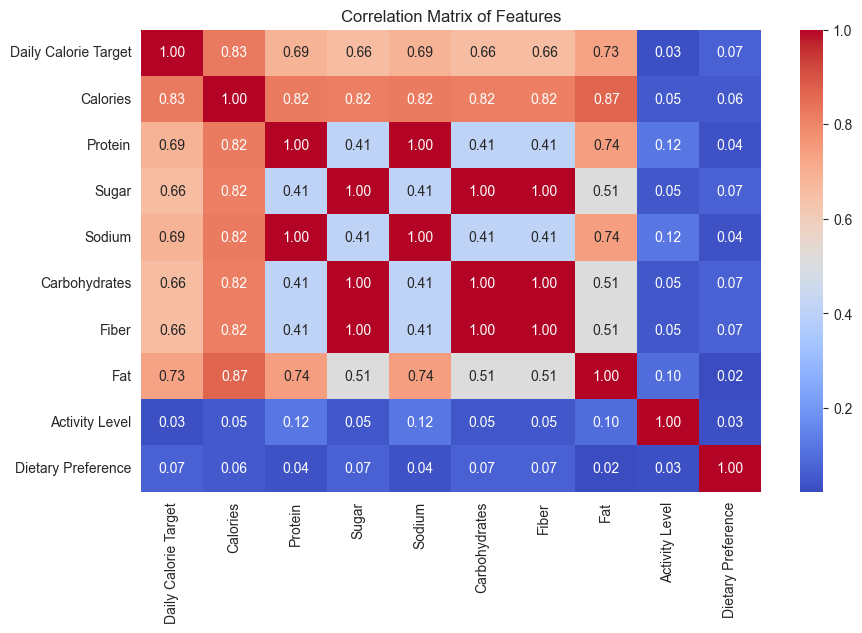

 Highly correlated features (correlation > 0.8):
['Calories', 'Protein', 'Sugar', 'Sodium', 'Carbohydrates', 'Fiber', 'Fat']

Remaining features after filtering:
['Daily Calorie Target', 'Activity Level', 'Dietary Preference']


In [141]:

#Compute correlation matrix
corr_matrix = X_scaled.corr().abs()

#Visualize correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()

#Identify highly correlated features (correlation > 0.8)

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]

print(" Highly correlated features (correlation > 0.8):")
print(high_corr_features if high_corr_features else "No highly correlated features found.")

# Drop correlated features for next steps
X_corr_filtered = X_scaled.drop(columns=high_corr_features, errors='ignore')
print("\nRemaining features after filtering:")
print(X_corr_filtered.columns.tolist())


#### 5.2.5 Principal Component Analysis

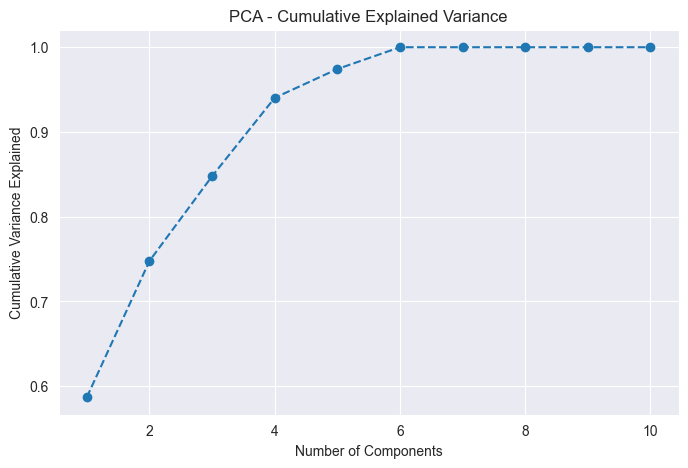

🔍 PCA Component Loadings (Top 3 Components):


,Daily Calorie Target,Calories,Protein,Sugar,Sodium,Carbohydrates,Fiber,Fat,Activity Level,Dietary Preference
0,0.356349,0.409744,0.328394,0.352740,0.328394,0.352740,0.352740,0.338854,-0.01904,-0.031284
1,0.072169,0.051729,0.425361,-0.392300,0.425361,-0.392300,-0.392300,0.251259,-0.31622,0.073676
2,-0.035319,0.009624,-0.071125,0.076948,-0.071125,0.076948,0.076948,-0.004358,-0.26669,0.948492


In [142]:

#Fit PCA on scaled features

pca = PCA()
pca.fit(X_scaled)


#Explained Variance Ratio
explained_var = np.cumsum(pca.explained_variance_ratio_)

#Plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', linestyle='--')
plt.title("PCA - Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.grid(True)
plt.show()

#Display top PCA Components

loadings = pd.DataFrame(pca.components_, columns=x.columns)
print("🔍 PCA Component Loadings (Top 3 Components):")
display(loadings.head(3))

#### 5.2.6 Random Forest Tree

Random Forest Accuracy: 0.6911764705882353

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.81       266
           1       0.23      0.18      0.20        74

    accuracy                           0.69       340
   macro avg       0.51      0.51      0.50       340
weighted avg       0.66      0.69      0.68       340


Confusion Matrix:
 [[222  44]
 [ 61  13]]


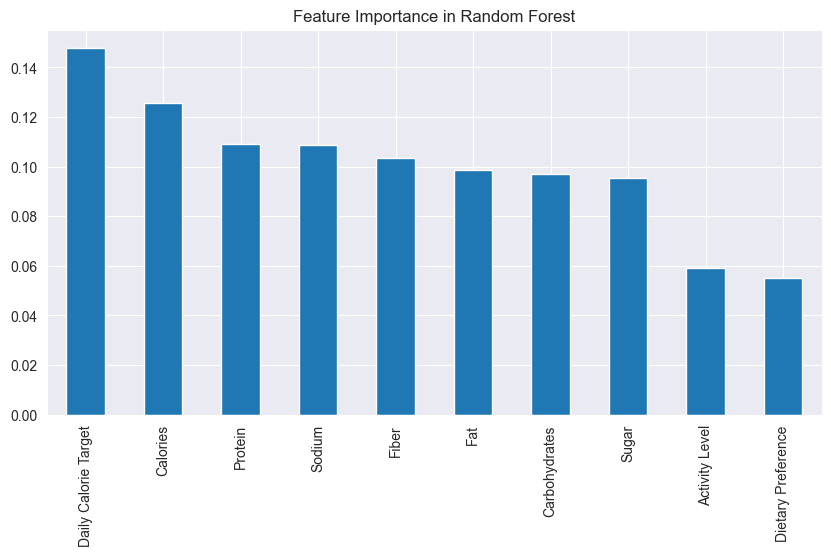

In [143]:
# Split data
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(x_train, y_train)

# Predictions and Evaluation
y_pred = rf_model.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature Importance plot
importances = pd.Series(rf_model.feature_importances_, index=x_train.columns)
importances.sort_values(ascending=False).plot(kind="bar", figsize=(10, 5), title="Feature Importance in Random Forest")
plt.show()


# 5.2.7 Backword/Forward Feature Selection

In [144]:
# Uses logistic regression as estimator

model = LogisticRegression(max_iter=500)

#Apply rfe to select top 5 features
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X_corr_filtered, y)

selected_features = X_corr_filtered.columns[rfe.support_].tolist()

print("Top features Selected")
print(selected_features)

#Create reduce dataset for modelling

X_selected= X_corr_filtered[selected_features]
X_selected.head()

Top features Selected
['Daily Calorie Target', 'Activity Level', 'Dietary Preference']


C:\Users\jjbed\Downloads\GroupPresentation4\.venv\Lib\site-packages\sklearn\feature_selection\_rfe.py:300: UserWarning: Found n_features_to_select=5 > n_features=3. There will be no feature selection and all features will be kept.
  warnings.warn(


,Daily Calorie Target,Activity Level,Dietary Preference
0,-0.492568,-0.196012,-1.263487
1,-1.208582,-1.001893,1.235039
2,-0.134561,0.609868,0.402197
3,0.402450,1.415749,-1.263487
4,-0.492568,0.609868,1.235039


#### 5.2.8 Box-Cox Transformation

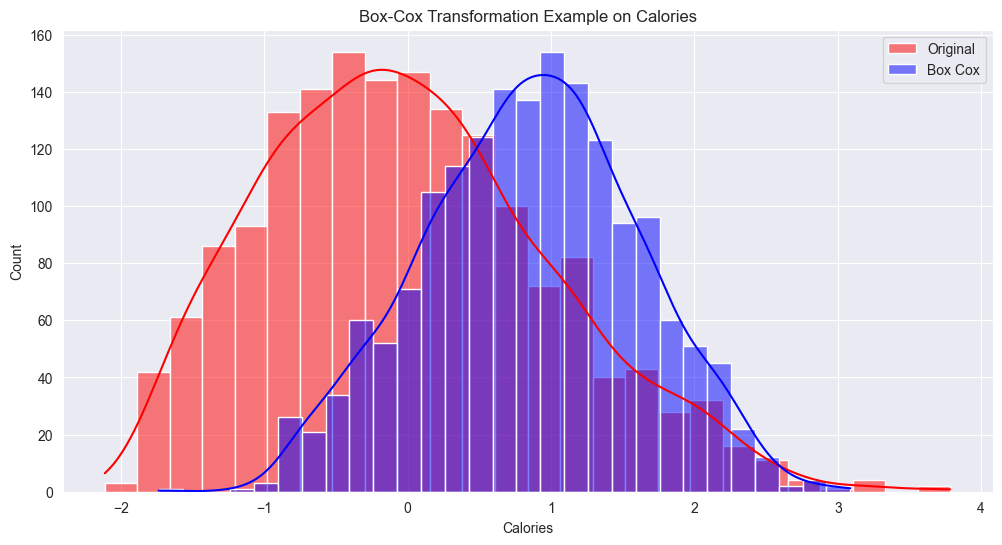

Box-Cox Transformation complete.


,Daily Calorie Target,Calories,Protein,Sugar,Sodium,Carbohydrates,Fiber,Fat,Activity Level,Dietary Preference
0,0.398971,0.702620,0.293264,0.747439,0.293264,0.747439,0.747439,0.372069,-0.196012,-1.263487
1,-0.303853,-0.146316,-0.494710,0.141037,-0.494710,0.141037,0.141037,-0.614918,-1.001893,1.235039
2,0.691884,0.920470,-0.063026,1.260519,-0.063026,1.260519,1.260519,0.568448,0.609868,0.402197
3,1.088125,1.507214,0.604651,1.716114,0.604651,1.716114,1.716114,1.096751,1.415749,-1.263487
4,0.398971,0.410034,-0.494710,0.747439,-0.494710,0.747439,0.747439,0.161521,0.609868,1.235039


In [145]:
# Apply  Box-cox only to positive continuous variables
numeric_cols = ["Daily Calorie Target", 'Calories', 'Protein', 'Sugar', 'Sodium', 'Carbohydrates', 'Fiber', 'Fat' ]
X_boxcox = X_scaled.copy()

for col in numeric_cols:
    min_val = X_boxcox[col].min()
    if min_val <=0:
        X_boxcox[col] = X_boxcox[col] - min_val + 1e-6 # shift to make all positive values
    X_boxcox[col], _ = boxcox(X_boxcox[col])




plt.figure(figsize=(12, 6))
sns.histplot(X_scaled['Calories'], kde=True, label='Original', color='red', alpha=0.5)
sns.histplot(X_boxcox['Calories'], kde=True, label='Box Cox', color='blue', alpha=0.5)
plt.title('Box-Cox Transformation Example on Calories')
plt.legend()
plt.show()

print("Box-Cox Transformation complete.")
X_boxcox.head()




##### Tukey's Ladder

In [146]:
# 5.3.0 – 
import numpy as np, pandas as pd

try:
    base_df_ccy = df_lowvar_filtered_ccy.copy()
except NameError:
    base_df_ccy = df.copy()

# 5.3.1 – Numerical columns and initial skewness
num_cols_ccy = base_df_ccy.select_dtypes(include=[np.number]).columns.tolist()
skew_before_ccy = base_df_ccy[num_cols_ccy].skew().sort_values(ascending=False)
print("The 10 most skewed numerical columns (first):\n", skew_before_ccy.head(10))

# Candidate columns: |skew| > 1 (you can set it to 0.8/1.5, etc. if you want)
SKEW_THRESH = 1.0
skewed_cols_ccy = skew_before_ccy[skew_before_ccy.abs() > SKEW_THRESH].index.tolist()
print("\nNumber of columns to be applied:", len(skewed_cols_ccy))
print(skewed_cols_ccy)


The 10 most skewed numerical columns (first):
 Dinner Protein.1           12.939795
Dinner Fats                11.380636
Breakfast Protein          10.723077
Lunch Carbohydrates         5.244070
Dinner Carbohydrates.1      5.132418
Lunch Protein               4.565463
Breakfast Calories          4.447732
Breakfast Carbohydrates     2.979638
Dinner Calories             2.569688
Lunch Calories              1.789961
dtype: float64

Number of columns to be applied: 11
['Dinner Protein.1', 'Dinner Fats', 'Breakfast Protein', 'Lunch Carbohydrates', 'Dinner Carbohydrates.1', 'Lunch Protein', 'Breakfast Calories', 'Breakfast Carbohydrates', 'Dinner Calories', 'Lunch Calories', 'Obesity']


In [147]:
# 5.3.2 – Helpers: positive structure + transformation + selecting the best lambda
def _make_positive_ccy(s: pd.Series, eps: float = 1e-9):
    s = s.astype(float)
    minv = s.min()
    offset = (1 - minv) if minv <= 0 else 0.0
    return s + offset + eps, offset

def _tukey_apply_ccy(s_pos: pd.Series, lam: float):
    if lam == 0:
        return np.log(s_pos)           # log
    else:
        return np.power(s_pos, lam)    # x^λ (negative λ -> 1/x^{|λ|})

def tukey_best_lambda_ccy(s: pd.Series, lambdas=None):
    if lambdas is None:
        lambdas = [-2, -1, -0.5, 0, 0.5, 1, 2]
    s_pos, offset = _make_positive_ccy(s)
    cand = {}
    for lam in lambdas:
        tr = pd.Series(_tukey_apply_ccy(s_pos, lam), index=s.index)
        cand[lam] = tr
    # |skew| the smallest lambda
    best_lam = min(cand, key=lambda L: abs(cand[L].skew()))
    return cand[best_lam], best_lam, offset


In [148]:
# 5.3.3 – Apply and report (ccy)
df_tukey_ccy = base_df_ccy.copy()
tukey_meta_ccy = {}

for col in skewed_cols_ccy:
    transformed, lam, offset = tukey_best_lambda_ccy(df_tukey_ccy[col])
    df_tukey_ccy[col] = transformed
    tukey_meta_ccy[col] = {"lambda": lam, "offset_added": offset}

# 5.3.4 – Before/After distortion comparison
skew_after_ccy = df_tukey_ccy[skewed_cols_ccy].skew().sort_values(ascending=False)

tukey_report_ccy = pd.DataFrame({
    "skew_before": skew_before_ccy.loc[skewed_cols_ccy],
    "skew_after":  skew_after_ccy,
    "lambda":      [tukey_meta_ccy[c]["lambda"] for c in skewed_cols_ccy],
    "offset":      [tukey_meta_ccy[c]["offset_added"] for c in skewed_cols_ccy],
}).sort_values("skew_before", ascending=False)

print("\nTukey Ladder report (in order of importance):")
display(tukey_report_ccy.head(20))

print("\nFigure (before/after):", base_df_ccy.shape, "->", df_tukey_ccy.shape)



Tukey Ladder report (in order of importance):


,skew_before,skew_after,lambda,offset
Dinner Protein.1,12.939795,-0.796306,0.5,1.0
Dinner Fats,11.380636,-0.267600,0.5,1.0
Breakfast Protein,10.723077,-1.396060,0.0,1.0
Lunch Carbohydrates,5.244070,-0.384726,0.5,1.0
Dinner Carbohydrates.1,5.132418,0.137813,0.0,1.0
Lunch Protein,4.565463,0.810914,0.5,1.0
Breakfast Calories,4.447732,0.925959,0.0,1.0
Breakfast Carbohydrates,2.979638,-0.843334,0.0,1.0
Dinner Calories,2.569688,0.688176,0.0,1.0
Lunch Calories,1.789961,0.140718,0.0,1.0



Figure (before/after): (1698, 32) -> (1698, 32)


#### Link to video


https://stuconestogacon-my.sharepoint.com/:v:/g/personal/mallahmoradi7818_conestogac_on_ca/EfbdIMb66YxBm1qiZDjf8awB3oFD4_SEWjniqXRqQAqK8A?e=3IqddP&nav=eyJyZWZlcnJhbEluZm8iOnsicmVmZXJyYWxBcHAiOiJTdHJlYW1XZWJBcHAiLCJyZWZlcnJhbFZpZXciOiJTaGFyZURpYWxvZy1MaW5rIiwicmVmZXJyYWxBcHBQbGF0Zm9ybSI6IldlYiIsInJlZmVycmFsTW9kZSI6InZpZXcifX0%3D

# Group Presentation 5 Portion

#### Hypothesis

🧪 Main Hypothesis
Null Hypothesis (H₀):

There is a significant relationship between an individual's activity level and their actual daily calorie intake.
That is, activity level does not meaningfully predict daily calorie intake

Alternative Hypothesis (H₁):

There is a significant relationship between an individual's activity level  and their daily calorie intake.
In other words, different activity levels correspond to measurable differences in total calories consumed in the day.

#### Simple Linear Regression Model
- Select the predictor and target variables
- Predictor (X): Activity Level (categorical)
- Target(y): Daily Calorie (numeric)

In [149]:
regression_df = macro_dataset[["Activity Level", "Calories"]].dropna()

#### Convert Activity Level to numeric form

In [150]:
#Convert Activity Level into numerical form
#We do this because Lienar regression requires numeric
#We use one-hot encoding to convert each activity category into a binary indicator

regression_df = pd.get_dummies(
    regression_df,
    columns=["Activity Level"],
    drop_first=True
)
bool_cols = regression_df.select_dtypes(include="bool").columns
regression_df[bool_cols] = regression_df[bool_cols].astype(int)

#### Separate predictors x and target y
x = regression_df.drop("Calories", axis=1) # Cannot use the thing we try to predict as predictor after dropping it x only contains the actual predictors we want which makes the regresison valid

y = regression_df["Calories"] # this is the variable we want o model and explain the regression will learn how each activity level changes Y


# Check data types after one-hot encoding
print(regression_df.dtypes)

# Check for any rows that might still contain non-numeric values
print("\nSample of the dataset:")
print(regression_df.head())



Calories                            int64
Activity Level_Lightly Active       int64
Activity Level_Moderately Active    int64
Activity Level_Sedentary            int64
Activity Level_Very Active          int64
dtype: object

Sample of the dataset:
   Calories  Activity Level_Lightly Active  Activity Level_Moderately Active  \
0      2020                              0                                 1   
1      1480                              1                                 0   
2      2185                              0                                 0   
3      2680                              0                                 0   
4      1815                              0                                 0   

   Activity Level_Sedentary  Activity Level_Very Active  
0                         0                           0  
1                         0                           0  
2                         1                           0  
3                         0            

#### Add an intercept (constant term) & Fit the Ordinary Least squares regression model

In [151]:
x = sm.add_constant(x)
#constant allows the model to learn the baseline value

model = sm.OLS(y,x).fit()

# Display model summary
print(model.summary())

#### Extract residuals and fitted values
residuals = model.resid

fitted_values=model.fittedvalues

                            OLS Regression Results                            
Dep. Variable:               Calories   R-squared:                       0.296
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     177.8
Date:                Fri, 21 Nov 2025   Prob (F-statistic):          3.04e-127
Time:                        21:45:53   Log-Likelihood:                -12889.
No. Observations:                1698   AIC:                         2.579e+04
Df Residuals:                    1693   BIC:                         2.582e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

OLS Regression: Activity level significant predicts calorie intake. The coefficients show how each level may differ from the baseline. THe predictors all are highlight significant which means the differences in activity meaningfully affect daily calories. Baseline calories represent the reference category expected intake

#### Homoscedasticity Test or Breusch-Pagen Test (name of import)

In [152]:
bp_test = het_breuschpagan(residuals, model.model.exog)
###review this
bp_labels = [
    "Lagrange Multiplier Statistic",
    "p-value",
    "f-statics",
    "F p-value"
]
print("\nBreusch-Pagen Test Results:")
for label, value in zip(bp_labels, bp_test):
    print(f"{label}: {value}")


Breusch-Pagen Test Results:
Lagrange Multiplier Statistic: 36.719696387571574
p-value: 2.05741162032133e-07
f-statics: 9.355201203700947
F p-value: 1.7715963360517492e-07


Breusch-Pagen Test: p-values are very small, indicating heterosexuality (meaning
Residual variance is not constant across activity levels. Coeffiecents remain unbiased but standard errors may be unreliable

#### Print R-squared
- Explains how much of the variation in Caloires target is explained by activity level

In [153]:
print (f"\nR-Squared: {model.rsquared}")


R-Squared: 0.29578402263714987


R-Squared; The model explains that approx 29.6% of the variation in actual calories. This shows a decent fit: Acivitiy level accounts for a meaningful, but not complete difference in calories. Other factors still likely contribute to intake more

### Final Summary
- Baseed on OLS, R-sqaured and p-values for activity level predictors we can come to teh conclusion that activity level is statically significant in predicting total daily calories, but  it only explains approx 30% of variation
- This may suggest that while it matters, activity level is not the main factor and other factors like dietary intake plays a bigger role
- Therefore the null hypothesis (H0) is rejected, but it is not the sole determinate of total daily calorie intake